# 11장 실습 — 계층으로 나눈다

3부의 마지막 장이다. 8~10장은 **하나의 정책**을 어떻게 돌릴 것인가를 다뤘다. 이 장은 정책을 둘로 쪼갠다.

느린 층이 **무엇을 할지**를 정하고, 빠른 층이 **지금 어떻게 움직일지**를 정한다. 문헌의 사례가 뚜렷하다.

- **GR00T N1** — 비전·언어 모델이 L40 GPU 에서 **10 Hz**, 액션 모듈이 **120 Hz** 다
- **Diffusion Policy** — 정책이 10 Hz, UR5 보간이 125 Hz, Franka 중간 제어가 약 1 kHz 다
- **AsyncVLA** — 큰 모델을 원격 워크스테이션에 두고 온보드의 가벼운 어댑터가 높은 주파수로 행동을 다듬는다. 통신 지연 **6초**까지 다룬다고 보고한다

NVIDIA 자신의 배포 문서도 같은 말을 한다 — **「액션 청킹 덕에 약 10 Hz 의 모델 주기가 30 FPS 실행을 비동기로 지탱한다」**.

이 노트북은 그 구조를 밀기 과제에 만들고, **계층이 없을 때와 있을 때 견디는 주기가 얼마나 달라지는지** 잰다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (67s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 두 층을 정한다

**느린 층**은 학습한 PPO 정책이다. K 스텝에 한 번만 부른다. 이것이 비싼 모델이다.

**빠른 층**은 매 스텝 돈다. 그리고 여기가 설계의 핵심이다 — 빠른 층은 **무엇을 할지 정하지 않는다.** 느린 층이 정해 준 것을 지금 관측에 맞춰 **따라가기만** 한다.

밀기 과제에서 느린 층이 넘겨 주는 것은 **밀대가 가야 할 자리**다. 관측에서 밀대와 블록의 상대 위치를 읽을 수 있으므로, 느린 층의 명령을 「이 방향으로 이만큼」이 아니라 **「블록 기준으로 여기」**로 바꿔 두면 빠른 층이 그 목표를 향해 비례 제어로 움직일 수 있다.

이 변환이 계층 구조의 값을 만든다. 절대 명령은 시간이 지나면 낡지만, **물체 기준의 목표는 덜 낡는다.** 3권 14장에서 상대 좌표계가 절대 좌표계를 크게 이겼던 것과 같은 구조다.

In [6]:
def plan(policy, o, K):
    """느린 층 — K 스텝 뒤 밀대가 블록에 대해 있어야 할 자리

    관측의 o[:, 4:6] 이 (블록 − 밀대) 를 10배 한 값이다.
    정책의 속도 명령을 K 스텝 적분해 목표 상대 위치로 바꾼다."""
    with torch.no_grad():
        a = policy.dist(torch.from_numpy(o)).sample().numpy()
    rel = o[:, 4:6] / 10.
    step = np.clip(a, -1, 1) * AMAX / 20. * K
    return (rel - step).astype(np.float32)


def track(o, tgt, K, kp=1.0):
    """빠른 층 — 지금 관측으로 목표까지의 오차를 다시 계산한다

    K 스텝에 걸쳐 오차를 닫는 속도를 낸다. 계획한 순간에는
    느린 층의 명령과 정확히 같고, 그 뒤로는 실제 위치에
    맞춰 보정된다."""
    rel = o[:, 4:6] / 10.
    v = (rel - tgt) * 20. / K * kp
    return np.clip(v / AMAX, -1, 1).astype(np.float32)


def run(policy, K, layered, cond="배포", seed=999, n=150, reps=2):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    tgt = None
    slow_a = np.zeros((n, 2), np.float32)
    sc, calls, steps = [], 0, 0
    for t in range(EP * reps):
        o = env.obs()
        if t % K == 0:
            calls += n
            if layered:
                tgt = plan(policy, o, K)
            else:
                with torch.no_grad():
                    slow_a = policy.dist(
                        torch.from_numpy(o)).sample().numpy()
        a = track(o, tgt, K) if layered else slow_a
        steps += n
        sc += env.step(a)[2]
    return np.array(sc), calls / steps

## 느린 층의 주기를 늘린다

K 를 키우면 비싼 모델을 덜 부른다. 계층이 없으면 그 사이 명령이 그대로 유지되고(8장의 열린 고리), 계층이 있으면 빠른 층이 매 스텝 보정한다.

In [7]:
t0 = time.time()
KS = [1, 2, 4, 8, 16, 32]
TAB = {}
for K in KS:
    for lay in (False, True):
        TAB[(K, lay)] = run(POLICY, K, lay)
    print(f"K={K} 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("느린 층 주기", 14) + pad("호출 주파수", 13, True)
      + pad("계층 없음", 12, True) + pad("계층 있음", 12, True)
      + pad("차이", 10, True))
for K in KS:
    a = TAB[(K, False)][0].mean()
    b = TAB[(K, True)][0].mean()
    print(pad(f"K = {K}", 14) + pad(f"{20 / K:.1f} Hz", 13, True)
          + pad(f"{a:.2f}", 12, True) + pad(f"{b:.2f}", 12, True)
          + pad(f"{(b - a) * 100:+.0f}pt", 10, True))
print()
print("배포 조건  ·  제어 주기 20 Hz 고정  ·  조건마다 300판")

K=1 끝  (9s)


K=2 끝  (18s)


K=4 끝  (27s)


K=8 끝  (35s)


K=16 끝  (43s)


K=32 끝  (51s)

느린 층 주기    호출 주파수   계층 없음   계층 있음      차이
K = 1               20.0 Hz        0.73        0.75      +2pt
K = 2               10.0 Hz        0.35        0.56     +21pt
K = 4                5.0 Hz        0.14        0.28     +14pt
K = 8                2.5 Hz        0.03        0.05      +2pt
K = 16               1.2 Hz        0.00        0.00      +0pt
K = 32               0.6 Hz        0.00        0.00      +0pt

배포 조건  ·  제어 주기 20 Hz 고정  ·  조건마다 300판


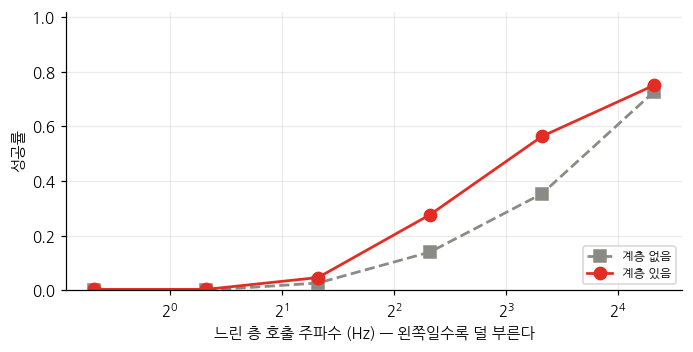

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
for lay, col, mk, lab in ((False, GREY, "s--", "계층 없음"),
                          (True, RED, "o-", "계층 있음")):
    ax.plot([20 / K for K in KS],
            [TAB[(K, lay)][0].mean() for K in KS], mk,
            color=col, lw=1.8, ms=8, label=lab)
ax.set_xscale("log", base=2)
ax.set_xlabel("느린 층 호출 주파수 (Hz) — 왼쪽일수록 덜 부른다")
ax.set_ylabel("성공률")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 빠른 층이 싸야 한다

계층 구조의 전제는 **빠른 층이 매 스텝 돌 만큼 싸다**는 것이다. 이 실습의 빠른 층은 비례 제어 한 줄이라 사실상 공짜다.

실제 시스템에서는 빠른 층도 신경망인 경우가 많다. GR00T N1 의 액션 모듈이 그렇고, AsyncVLA 의 온보드 어댑터가 그렇다. 그래도 느린 층보다 **한두 자릿수 작다**는 것이 공통점이다.

빠른 층의 비용을 재 본다.

In [9]:
o = Vec(150, seed=1).obs()
tgt = plan(POLICY, o, 8)
runs = {}
for lab, fn in (("느린 층 (PPO)", lambda: plan(POLICY, o, 8)),
                ("빠른 층 (비례 제어)", lambda: track(o, tgt, 8))):
    ts = []
    for i in range(400):
        t0 = time.perf_counter_ns()
        fn()
        if i >= 50:
            ts.append((time.perf_counter_ns() - t0) / 1e3)
    runs[lab] = np.array(ts)

print(pad("층", 22) + pad("p50 μs", 11, True)
      + pad("p99 μs", 11, True) + pad("느린 층 대비", 14, True))
base = np.percentile(runs["느린 층 (PPO)"], 50)
for lab, v in runs.items():
    p50 = np.percentile(v, 50)
    print(pad(lab, 22) + pad(f"{p50:.0f}", 11, True)
          + pad(f"{np.percentile(v, 99):.0f}", 11, True)
          + pad(f"{p50 / base * 100:.0f}%", 14, True))
print()
print("150판을 한 번에 처리한 시간")

층                         p50 μs     p99 μs  느린 층 대비
느린 층 (PPO)                 249        368          100%
빠른 층 (비례 제어)            11         37            4%

150판을 한 번에 처리한 시간


## 무엇이 계층을 가능하게 하는가

이 실습에서 계층이 값을 한 이유는 **빠른 층이 쓰는 목표가 잘 늙지 않기 때문**이다.

느린 층이 「초속 0.3 으로 오른쪽」이라고 말하면 그 명령은 한 스텝만 지나도 낡는다. 로봇이 이미 움직였기 때문이다. 대신 **「블록 기준으로 여기에 있어라」**라고 말하면, 로봇이 움직여도 블록이 움직여도 그 목표는 여전히 말이 된다. 빠른 층이 매 스텝 새 관측으로 그 목표까지의 오차를 다시 계산하면 된다.

3권 14장에서 절대 좌표계 0.15 대 상대 좌표계 0.72 였던 것과 같은 구조다. **표현이 불변성을 주면 데이터도 주파수도 덜 든다.**

그래서 계층 설계의 질문은 「무엇을 쪼갤 것인가」가 아니라 **「느린 층이 무엇을 넘겨 줄 것인가」**다. 넘기는 것이 잘 늙는 양이면 계층을 나눠도 소용이 없다.

In [10]:
def run_stale(policy, K, cond="배포", seed=999, n=150, reps=2):
    """느린 층이 '절대 속도 명령'을 넘길 때 — 잘 늙는 양"""
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    hold = np.zeros((n, 2), np.float32)
    sc = []
    for t in range(EP * reps):
        o = env.obs()
        if t % K == 0:
            with torch.no_grad():
                hold = policy.dist(
                    torch.from_numpy(o)).sample().numpy()
        sc += env.step(hold)[2]
    return np.array(sc)


print(pad("느린 층 주기", 14) + pad("절대 속도 명령", 16, True)
      + pad("상대 목표 위치", 16, True))
for K in (4, 8, 16, 32):
    a = run_stale(POLICY, K).mean()
    b = TAB[(K, True)][0].mean()
    print(pad(f"K = {K}", 14) + pad(f"{a:.2f}", 16, True)
          + pad(f"{b:.2f}", 16, True))

느린 층 주기    절대 속도 명령  상대 목표 위치


K = 4                     0.14            0.28


K = 8                     0.03            0.05


K = 16                    0.00            0.00


K = 32                    0.00            0.00


## 정리

**계층은 느린 층의 주기를 늘려 준다.** 같은 정책을 같은 주기로 부르는데, 빠른 층이 매 스텝 보정하면 훨씬 낮은 주파수를 견딘다.

**빠른 층은 무엇을 할지 정하지 않는다.** 느린 층이 정한 것을 지금 관측에 맞춰 따라가기만 한다. 그래서 싸도 된다.

**넘기는 양이 잘 늙지 않아야 한다.** 절대 속도 명령은 한 스텝이면 낡고, 물체 기준의 목표 위치는 오래 간다. 계층의 값은 쪼개는 데 있는 것이 아니라 **무엇을 넘기는가**에 있다.

**문헌의 주파수 비가 이 구조에서 나온다.** GR00T N1 의 10 Hz 와 120 Hz, Diffusion Policy 의 10 → 125 → 1000 Hz 사다리가 전부 같은 설계다.

3부가 끝났다. 지연을 없애는 대신 **지연을 전제로 설계하는** 네 가지 장치를 봤다 — 청킹으로 예산을 늘리고, 시간 앙상블의 비용을 알고, 비동기로 멈춤을 없애고, 계층으로 주기를 나눴다.

4부는 다른 질문으로 간다. 이렇게 만든 시스템이 **모를 때 무엇을 해야 하는가.**